In [61]:
import sys
sys.path.insert(0, '../../')
import time
import numpy as np
import matplotlib.pyplot as plt
from deepssfp import ssfp, recon

def generate_training_data_pts(num_samples=100, num_pcs=4):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []

    for i in range(num_samples):
        M_2pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        X.append(M_2pc)
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        y.append(np.sqrt(np.mean(np.abs(M_4pc)**2)))
    
    return np.array(X), np.array(y)

def generate_training_data_1d(num_samples=100, num_pcs=4, width = 128):
    T1 = np.random.uniform(0.5, 2.0, num_samples); T1 = np.tile(T1, (width, 1)).T
    T2 = np.random.uniform(0.01, 0.1, num_samples); T2 = np.tile(T2, (width, 1)).T
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, width)
    f = beta / TR / (2 * np.pi)
    f = np.tile(f, (num_samples, 1))
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    print(T1.shape, f.shape)

    M_2pc = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=f)
    X = M_2pc
    M_4pc = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
    Y = np.sqrt(np.mean(np.abs(M_4pc)**2))
    
    return np.array(X), np.array(y)

def generate_training_data_2d():
    pass

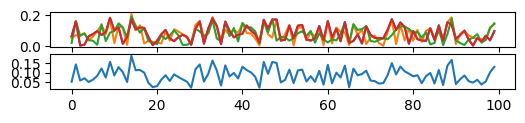

In [62]:
x, y = generate_training_data_pts()

fig, axs = plt.subplots(2, 1, figsize=(6, 1))
axs[0].plot(np.abs(x))
axs[1].plot(np.abs(y))
plt.show()

(100, 128) (100, 128)
[[[-0.00600073-1.69696110e-17j -0.07598297+4.13718186e-02j
   -0.07598297-4.13718186e-02j -0.00600073-3.32043449e-17j]
  [-0.00598582-6.84402499e-03j -0.07507399+4.05910911e-02j
   -0.07674846-4.20654554e-02j -0.00598582-6.84402499e-03j]
  [-0.00594142-1.36199057e-02j -0.0740048 +3.97137100e-02j
   -0.0773857 -4.26808437e-02j -0.00594142-1.36199057e-02j]
  ...
  [-0.00594142+1.36199057e-02j -0.0773857 +4.26808437e-02j
   -0.0740048 -3.97137100e-02j -0.00594142+1.36199057e-02j]
  [-0.00598582+6.84402499e-03j -0.07674846+4.20654554e-02j
   -0.07507399-4.05910911e-02j -0.00598582+6.84402499e-03j]
  [-0.00600073+1.69696110e-17j -0.07598297+4.13718186e-02j
   -0.07598297-4.13718186e-02j -0.00600073+7.34877159e-19j]]

 [[-0.00470373-1.46240418e-17j -0.06801924+3.72351442e-02j
   -0.06801924-3.72351442e-02j -0.00470373-2.86720422e-17j]
  [-0.00469287-5.89905986e-03j -0.06707984+3.64879897e-02j
   -0.06882276-3.79013622e-02j -0.00469287-5.89905986e-03j]
  [-0.00466047-1.1

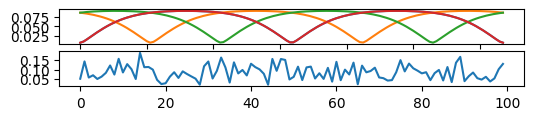

In [63]:
x, y = generate_training_data_1d()
print(y.shape)
fig, axs = plt.subplots(2, 1, figsize=(6, 1))
axs[0].plot(np.abs(x[0,:,:]))
axs[1].plot(np.abs(y))
plt.show()

Time elapsed: 0.006489753723144531
(128, 128, 4)


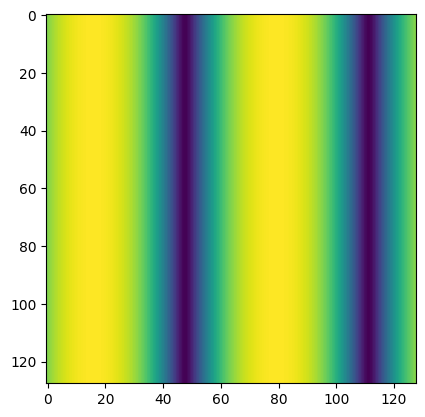

In [64]:
N = 128
T1, T2 = 1.2 * np.ones((N, N)), .035 * np.ones((N, N))
TR, alpha = 5e-3, np.deg2rad(30)
TE = TR / 2.0
BetaMax = 2 * np.pi
beta = np.linspace(-BetaMax, BetaMax, N)
f = beta / TR / (2 * np.pi)
f = np.tile(f, (N, 1))
npcs = 4
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

start_time = time.time()
M2 = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, field_map=f)
print('Time elapsed:', time.time() - start_time)
print(M2.shape)

plt.imshow(abs(M2[:,:,1]))
plt.show()